# Training Model on Arabic data set only (EYASE)


## Preparing the data

In [1]:
import os
import shutil

source_root = r"H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE"
target_root = r"H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion"

emotions = ["hap", "sad", "neu", "ang"]

for emotion in emotions:
    os.makedirs(os.path.join(target_root, emotion), exist_ok=True)

for speaker_folder in os.listdir(source_root):
    speaker_path = os.path.join(source_root, speaker_folder)

    if not os.path.isdir(speaker_path):
        continue

    for filename in os.listdir(speaker_path):
        if not filename.lower().endswith(".wav"):
            continue

        filename_lower = filename.lower()

        for emotion in emotions:
            if emotion in filename_lower:
                source_file = os.path.join(speaker_path, filename)

                new_filename = f"{speaker_folder}_{filename}"
                target_file = os.path.join(target_root, emotion, new_filename)

                shutil.copy2(source_file, target_file)
                break

print("Done. Files copied by emotion.")

Done. Files copied by emotion.


## EYASE VGG Model

### Creating Mel Spectrograms

In [2]:
import librosa
import soundfile as sf
import os
import numpy as np
data_path = r'H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion'

print("Cleaning and standardizing files...")

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            try:
                # 1. Load with librosa (ignores bad headers, handles stereo -> mono)
                y, sr = librosa.load(path, sr=48000, mono=True)

                # 2. Force length to exactly 3 seconds (144,000 samples)
                target_len = 144000
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]

                # 3. Overwrite the file with a 'Clean' version
                # soundfile writes pure PCM data without the weird metadata TF hates
                sf.write(path, y, sr, subtype='PCM_16')

            except Exception as e:
                print(f"Failed to fix {path}: {e}")

print("Sanitization complete. Your folder is now 'TensorFlow-Ready'.")

Cleaning and standardizing files...
Sanitization complete. Your folder is now 'TensorFlow-Ready'.


### Data Splitting

In [3]:
import numpy as np
import tensorflow as tf
# Re-run this to fix the variable length issue
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=r'H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion',
    batch_size=None,
    validation_split=0.2,
    seed=0,
    output_sequence_length=144000, # Fixed length (3 seconds)
    subset='both')

label_names = np.array(train_ds.class_names)
print(label_names)

Found 579 files belonging to 4 classes.
Using 464 files for training.
Using 115 files for validation.
['ang' 'hap' 'neu' 'sad']


### Mel Spectrogram Function

In [4]:
def get_mel_spectrogram_librosa(audio_tensor, label):
    def _process_audio(audio_np):
        # Handle Stereo-to-Mono conversion
        if len(audio_np.shape) > 1 and audio_np.shape[-1] > 1:
            audio_np = np.mean(audio_np, axis=-1)

        audio_np = np.squeeze(audio_np)  # remove dimensions of size 1

        # Generate the Mel Spectrogram
        S = librosa.feature.melspectrogram(
            y=audio_np,
            sr=48000,
            n_fft=1024,  # Number of samples in chunk thats being analyzed
            hop_length=512,  # Number of samples to hop before creating the new chunk
            n_mels=80,  # How many frequency bins,
            fmin=80.0,
            fmax=8000.0
        )

        log_S = librosa.power_to_db(S, ref=np.max)  # convert to decibel (logarithmic scale) , easier to interpret
        return log_S.astype(np.float32)[..., np.newaxis]

    [mel_spec] = tf.py_function(_process_audio, [audio_tensor], [tf.float32])

    # Define the expected shape for the single image
    mel_spec.set_shape([80, None, 1])

    return mel_spec, label


def prepare_dataset(ds):
    return ds.map(get_mel_spectrogram_librosa, num_parallel_calls=tf.data.AUTOTUNE)


train_spectrogram_ds = prepare_dataset(train_ds)
val_spectrogram_ds = prepare_dataset(val_ds)

# Now it's safe to batch!
train_spectrogram_ds = train_spectrogram_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(get_mel_spectrogram_librosa).batch(64).prefetch(tf.data.AUTOTUNE)

### Import VGG

In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# 1. Update the input shape to match your ACTUAL Mel Spectrograms
# Based on your previous run, it's something like (80, 282, 1) or (80, 1125, 1)
# Let's pull it from your input_shape variable
mel_height = 80
input_shape = (1124, 80, 1)
num_labels = len(label_names)
mel_width = input_shape[1] # Use the width from your dataset

model_vgg = models.Sequential([
    layers.Input(shape=(mel_height, mel_width, 1)),

    # OPTIONAL: Use Resizing only if the image is too large for your GPU
    # but keep it at a decent resolution (e.g., 128x128 or 224x224)
    # layers.Resizing(128, 256),

    # Convert 1 channel (Grayscale) to 3 channels (RGB) for VGG16
    layers.Conv2D(3, (3, 3), padding='same'),

    # The VGG16 Base (Pre-trained on ImageNet)
    VGG16(weights='imagenet', include_top=False, input_shape=(None, None, 3)),

    # Global Average Pooling is better than Flatten for audio
    layers.GlobalAveragePooling2D(),

    # Final Classification Layers
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels, activation='softmax')
])

# --- FINE-TUNING STEP ---
# Initially, we freeze the whole VGG base
model_vgg.layers[1].trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Low learning rate for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model_vgg.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 80, 80, 3)         30        
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 2052      
                                                        

In [6]:
# Unfreeze the VGG16 base
model_vgg.layers[1].trainable = True

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Cut learning rate in half when progress stalls
    patience=2,      # Wait only 2 epochs before slowing down
    min_lr=1e-6,     # Don't let it get slower than this
    verbose=1
)

# Re-compile with an EXTREMELY low learning rate
# You don't want to "break" the pre-trained weights, just nudge them
model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = model_vgg.fit(train_spectrogram_ds, validation_data=val_spectrogram_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
8/8 [==============================] - 57s 7s/step - loss: 2.1204 - accuracy: 0.2716 - val_loss: 1.3325 - val_accuracy: 0.3739
Epoch 2/50
8/8 [==============================] - 56s 7s/step - loss: 1.4668 - accuracy: 0.2888 - val_loss: 1.2788 - val_accuracy: 0.4261
Epoch 3/50
8/8 [==============================] - 57s 7s/step - loss: 1.4172 - accuracy: 0.3319 - val_loss: 1.2598 - val_accuracy: 0.4696
Epoch 4/50
8/8 [==============================] - 56s 7s/step - loss: 1.3126 - accuracy: 0.3901 - val_loss: 1.2556 - val_accuracy: 0.4870
Epoch 5/50
8/8 [==============================] - 57s 7s/step - loss: 1.2481 - accuracy: 0.4591 - val_loss: 1.1824 - val_accuracy: 0.5304
Epoch 6/50
8/8 [==============================] - 57s 7s/step - loss: 1.2269 - accuracy: 0.4784 - val_loss: 1.1396 - val_accuracy: 0.5043
Epoch 7/50
8/8 [==============================] - 58s 7s/step - loss: 1.1461 - accuracy: 0.4978 - val_loss: 1.0960 - val_accuracy: 0.5391
Epoch 8/50
8/8 [==================

### Validation Accuracy Plot

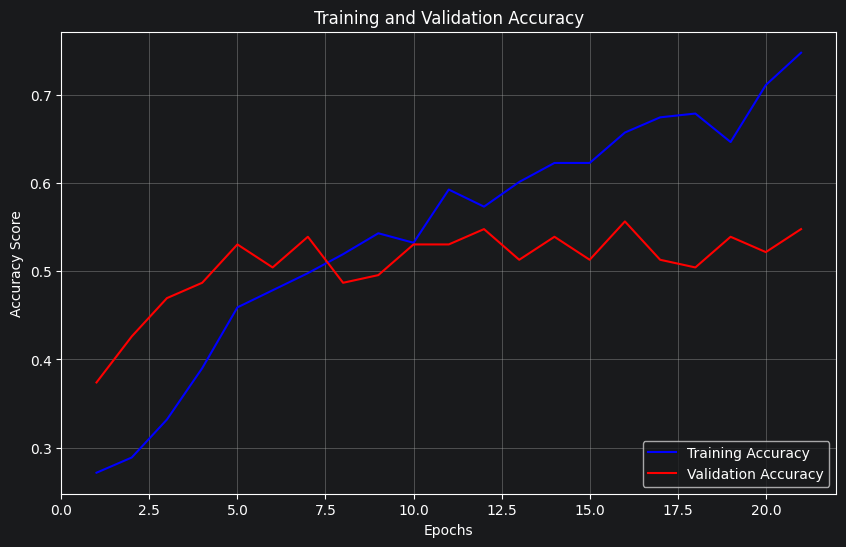

In [7]:
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))

    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history_finetune.history['accuracy']
    val_acc = history_finetune.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.savefig('accuracy_plot.png')
plot_accuracy(history_finetune)


### Confusion Matrix

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for x_batch, y_batch in val_spectrogram_ds:
    preds = model_vgg.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_names
))

ValueError: in user code:

    File "H:\conda_envs\gpu_env\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "H:\conda_envs\gpu_env\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "H:\conda_envs\gpu_env\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "H:\conda_envs\gpu_env\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "H:\conda_envs\gpu_env\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "H:\conda_envs\gpu_env\lib\site-packages\keras\engine\input_spec.py", line 295, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 of layer "seq

### Showcasing 10 random samples

In [ ]:
import random
import matplotlib.pyplot as plt
import IPython.display as ipd
import tensorflow as tf
import numpy as np

all_x = []
all_y = []
all_audio = []

for (x_batch, y_batch), (audio_batch, _) in zip(val_spectrogram_ds, val_ds.batch(64)):
    all_x.append(x_batch)
    all_y.append(y_batch)
    all_audio.append(audio_batch)

all_x = tf.concat(all_x, axis=0)
all_y = tf.concat(all_y, axis=0)
all_audio = tf.concat(all_audio, axis=0)

idxs = random.sample(range(len(all_y)), 10)

for idx in idxs:
    x = all_x[idx:idx+1]
    true_label = label_names[all_y[idx].numpy()]

    preds = model_vgg.predict(x, verbose=0)
    pred_label = label_names[np.argmax(preds)]
    conf = np.max(preds)

    print("=" * 50)
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {conf:.2f}")

    display(ipd.Audio(tf.squeeze(all_audio[idx]).numpy(), rate=48000))

    plt.figure(figsize=(5, 3))
    plt.imshow(tf.squeeze(all_x[idx]).numpy(), aspect="auto", origin="lower")
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.colorbar()
    plt.show()

In [9]:
model_vgg.save("Eyase_Model.keras")

## EYASE Model with data augmentation